In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [18]:
ds= pd.read_csv('DS_Companies.csv')

In [19]:
ds

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [20]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [21]:
ds= ds.drop(ds[['Unnamed: 0','salary']], axis=1)

In [22]:
ds.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


In [23]:
ds.work_year.unique()

array([2020, 2021, 2022])

In [33]:
ds1 = ds.groupby('work_year')['salary_in_usd'].mean().round(2)

making data frame

In [46]:
data={
    'Work_Year' : ds1.index,
    'Avr_Salary' : ds1.values
}
df1 = pd.DataFrame(data)
df1

,Work_Year,Avr_Salary
0,2020,95813.00
1,2021,99853.79
2,2022,124522.01


In [47]:
df1.Avr_Salary= (df1.Avr_Salary/1000).round(2)

In [48]:
df1

,Work_Year,Avr_Salary
0,2020,95.81
1,2021,99.85
2,2022,124.52


<Axes: xlabel='Work_Year'>

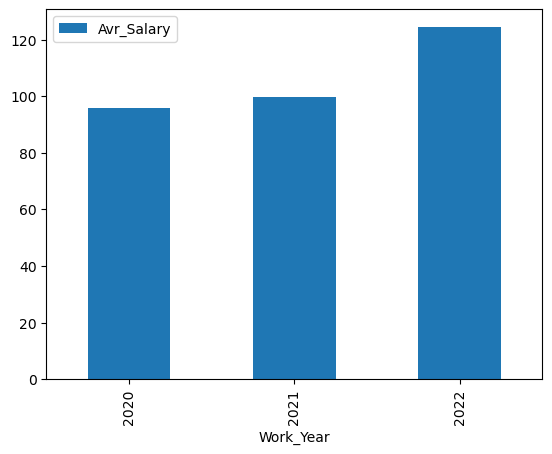

In [50]:
df1.plot(kind='bar',x = 'Work_Year',y = 'Avr_Salary')

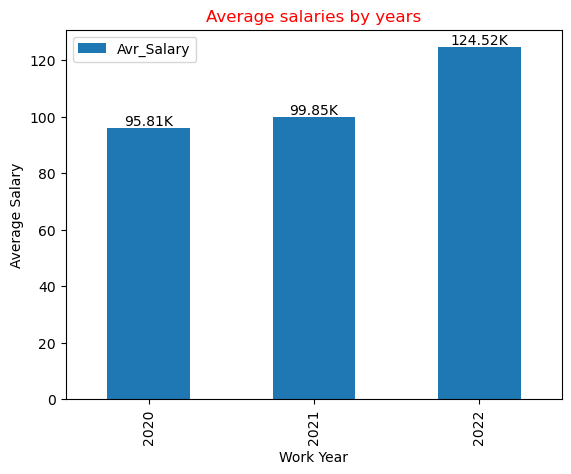

In [53]:
ax= df1.plot(kind='bar',x = 'Work_Year',y = 'Avr_Salary',legend='true')
ax.bar_label(ax.containers[0], labels = df1['Avr_Salary'].map('{:.2f}K'.format))
ax.legend(['Avr_Salary'], loc = 'upper left')
plt.xlabel('Work Year')
plt.ylabel('Average Salary')
plt.title('Average salaries by years', color = 'red')
plt.show()

In [55]:
ds.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


In [59]:
ds.remote_ratio.unique()

array([  0,  50, 100])

In [60]:
df2= ds.remote_ratio.value_counts()

In [61]:
df2

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

In [63]:
df2.to_list() 

[381, 127, 99]

In [64]:
values= df2.to_list()

In [66]:
Labels=['Online','Onsite','Hybrid']


In [67]:
Labels

['Online', 'Onsite', 'Hybrid']

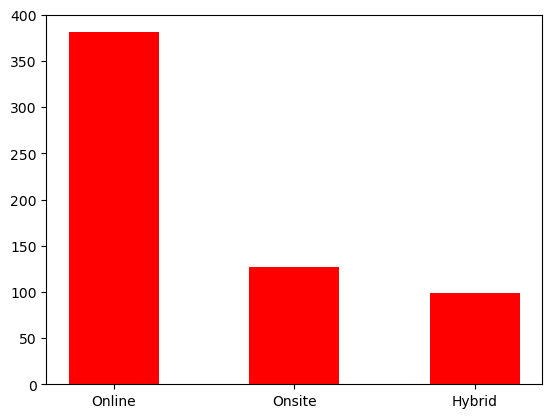

In [68]:
z=plt.bar(Labels,values,width=0.5,color='red')

Text(0.5, 0, 'Status')

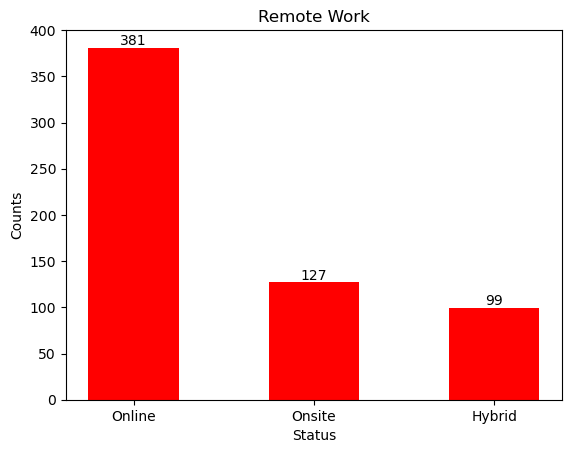

In [74]:
z=plt.bar(Labels,values,width=0.5,color='red')
plt.bar_label(z,labels=values)
plt.title('Remote Work')
plt.ylabel('Counts')
plt.xlabel('Status')

In [76]:
ds.company_size.unique()

array(['L', 'S', 'M'], dtype=object)

In [79]:
df3 = ds.company_size.value_counts()

In [80]:
df3

company_size
M    326
L    198
S     83
Name: count, dtype: int64

In [81]:
values2=df3.to_list()

In [82]:
Company_Label=['Medium','Large','Small']

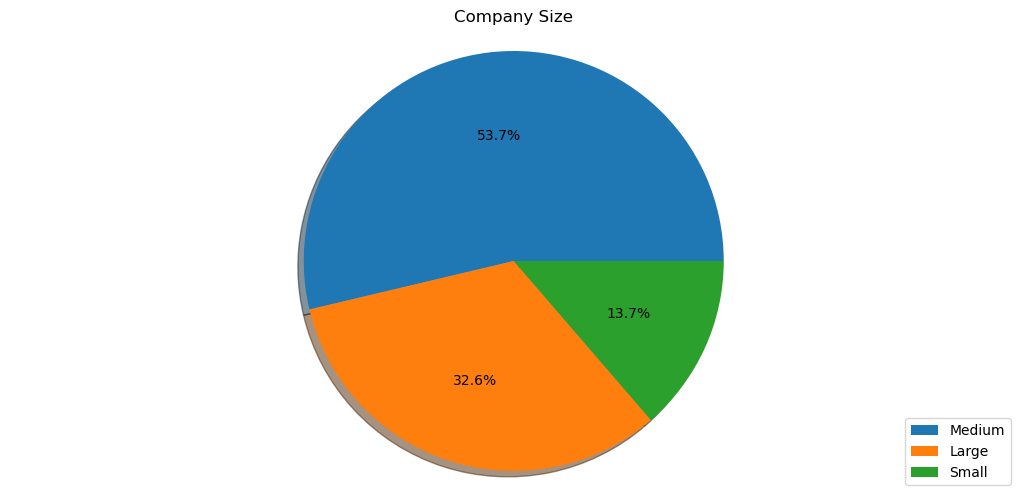

In [85]:
plt.figure(figsize = (13,6))
plt.pie(x = values2, labels = None, autopct = '%1.1f%%', shadow = True)
plt.legend(labels = Company_Label, loc = 'lower right')
plt.axis('equal')
plt.title("Company Size")
plt.show()

In [87]:
ds.job_title.value_counts().head(10)

job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Big Data Engineer               8
Machine Learning Scientist      8
Principal Data Scientist        7
Name: count, dtype: int64

In [88]:
df4 = ds.job_title.value_counts().head(10)

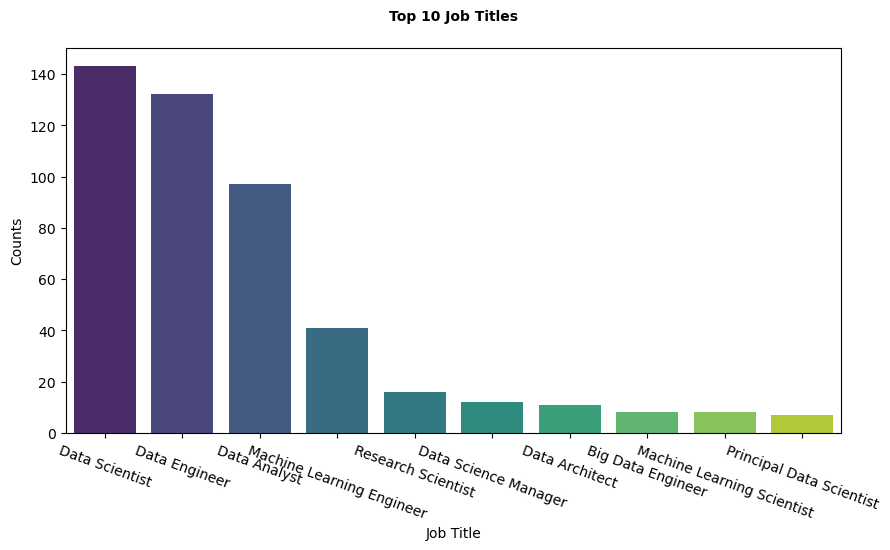

In [91]:
plt.figure(figsize = (10,5))
sns.barplot(x = df4.index, y = df4.values, palette= "viridis")
plt.title('Top 10 Job Titles', fontweight = 'bold', fontsize = 10, pad = 20)
plt.ylabel('Counts')
plt.xlabel('Job Title')
plt.xticks(rotation = -20)
plt.show()

In [134]:
df5= ds[['salary_in_usd','company_size']]

In [100]:
df5.head()

,salary_in_usd,company_size
0,79833,L
1,260000,S
2,109024,M
3,20000,S
4,150000,L


In [135]:
##S = df5[df5.company_size == 'S']
##M = df5[df5.company_size == 'M']
##L = df5[df5.company_size == "L"]
##ds2 = df5.groupby('company_size',as_index = False)['salary_in_usd'].mean().round(2)
#sal_mean = [S['salary_in_usd'].mean(), M["salary_in_usd"].mean(), L["salary_in_usd"].mean()]
#sal_mean

In [136]:
##ds2 = df5.groupby('company_size',as_index = False)['salary_in_usd'].mean().round(2)

In [137]:
##Values= df5['salary_in_usd']

In [119]:
##CS_Label=['Large','Medium','Small']

In [148]:
##dataq={
    ##'Company Size' :ds2.index,
  ##  'Mean' : ds2.values
##}
##df5 = pd.DataFrame(dataq)
##df5

In [146]:
S = df5[df5['company_size'] == 'S']
M = df5[df5['company_size'] == 'M']
L = df5[df5['company_size'] == "L"]

labels = ['Small','Medium', 'Large']
sal_mean = [S['salary_in_usd'].mean(), M["salary_in_usd"].mean(), L["salary_in_usd"].mean()]
sal_mean

[np.float64(77632.67469879518),
 np.float64(116905.46625766871),
 np.float64(119242.99494949495)]

In [147]:
label_change = np.round([x for x in sal_mean], 1)
# label_change
label_change = list(map(str, label_change))
label_change = [x + '$' for x in label_change]
label_change


['77632.7$', '116905.5$', '119243.0$']

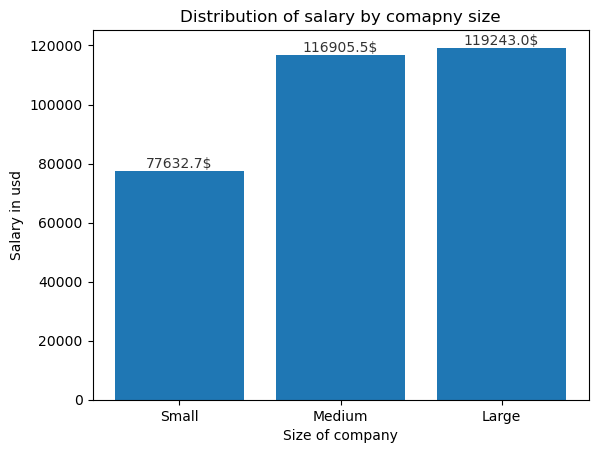

In [149]:
z = plt.bar(labels, sal_mean)
plt.bar_label(z,label_change, alpha = 0.8)
plt.title('Distribution of salary by comapny size')
plt.xlabel('Size of company')
plt.ylabel('Salary in usd')
plt.show()

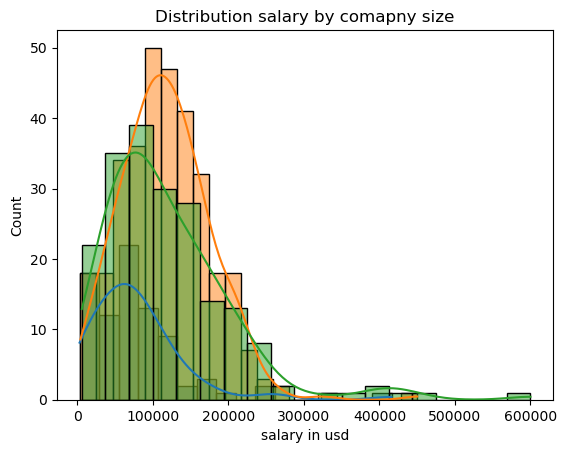

In [151]:
sns.histplot(S['salary_in_usd'], label = 'Small', kde = True)
sns.histplot(M['salary_in_usd'], label = 'Medium', kde = True)
sns.histplot(L['salary_in_usd'], label = 'Large', kde = True)
plt.title('Distribution salary by comapny size')
plt.xlabel('salary in usd')
plt.show()

In [144]:
##df5.columns = df5.columns.str.strip()
##ds2 = df5.groupby('company_size', as_index=False)['salary_in_usd'].mean().round(2) 

In [106]:
S.head()

,salary_in_usd,company_size
1,260000,S
3,20000,S
6,190000,S
9,125000,S
10,51321,S


In [107]:
CS_Lable= ['Small','Medium','Large']

In [108]:
CS_Lable

['Small', 'Medium', 'Large']

In [93]:
ds.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,USD,150000,US,50,US,L


In [29]:
ds1

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x00000207614141A0>>